   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.4 MB/s eta 0:00:00
1. Loading Pantheon+ and Cosmic Chronometers data...

2. Running MCMC with 3 free parameters...


100%|██████████| 2000/2000 [04:43<00:00,  7.05it/s]


-> MCMC completed in 283.68 seconds.

JOINT ANALYSIS RESULTS (3 PARAMETERS):
$H_0$     : 72.520 +0.285 / -0.260
$\alpha$  : 0.060 +0.007 / -0.008
$z_c$     : 0.112 +0.023 / -0.023
--------------------------------------------------
Total data points (N)    : 1622
Free parameters (k)      : 3
Best-fit Joint Chi2      : 1468.72
AIC                      : 1474.72
BIC                      : 1490.90


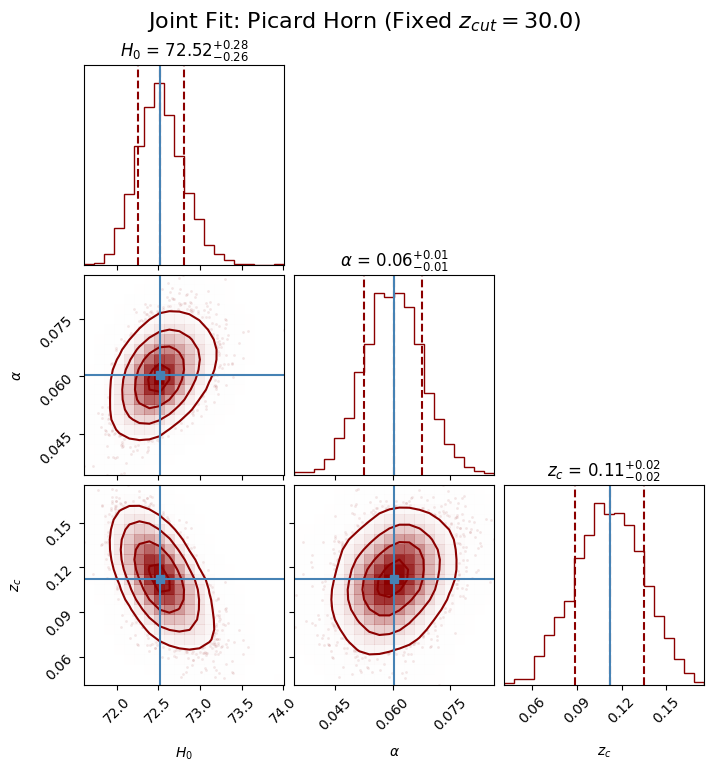

In [ ]:
# Install required packages if not already installed
!pip install emcee corner

import numpy as np
import pandas as pd
import urllib.request
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import time

# =====================================================================
# 1. LOAD DATA (PANTHEON+ & COSMIC CHRONOMETERS)
# =====================================================================
print("1. Loading Pantheon+ and Cosmic Chronometers data...")
url_data = "https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat"
url_cov = "https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov"

df = pd.read_csv(url_data, sep=r'\s+')
response = urllib.request.urlopen(url_cov)
lines = response.readlines()
N_points = int(lines[0].decode('utf-8').strip())
C_matrix = np.loadtxt(lines[1:]).reshape((N_points, N_points))

df['original_index'] = np.arange(len(df))
data_filtered = df[df['zHD'] > 0.01].copy().sort_values(by='zHD')
keep_indices = data_filtered['original_index'].values

C_filtered = C_matrix[keep_indices, :][:, keep_indices]
C_inv = np.linalg.inv(C_filtered)

z_sn = data_filtered['zHD'].values
mu_sn = data_filtered['MU_SH0ES'].values
c = 299792.458

cc_data = np.array([
    [0.070, 69.0, 19.6],  [0.090, 69.0, 12.0],  [0.120, 68.6, 26.2],
    [0.170, 83.0, 8.0],   [0.179, 75.0, 4.0],   [0.199, 75.0, 5.0],
    [0.200, 72.9, 29.6],  [0.240, 79.6, 2.6],   [0.270, 77.0, 14.0],
    [0.280, 88.8, 36.6],  [0.352, 83.0, 14.0],  [0.3802, 83.0, 13.5],
    [0.400, 95.0, 17.0],  [0.4004, 77.0, 10.2], [0.4247, 87.1, 11.2],
    [0.4497, 92.8, 12.9], [0.470, 89.0, 50.0],  [0.4783, 80.9, 9.0],
    [0.480, 97.0, 62.0],  [0.593, 104.0, 13.0], [0.680, 92.0, 8.0],
    [0.781, 105.0, 12.0], [0.875, 125.0, 17.0], [0.880, 90.0, 40.0],
    [0.900, 117.0, 23.0], [1.037, 154.0, 20.0], [1.300, 168.0, 17.0],
    [1.363, 160.0, 33.6], [1.430, 177.0, 18.0], [1.530, 140.0, 14.0],
    [1.750, 202.0, 40.0], [1.965, 186.5, 50.4]
])
z_cc = cc_data[:, 0]
H_cc = cc_data[:, 1]
err_cc = cc_data[:, 2]

N_total = len(z_sn) + len(z_cc)

# =====================================================================
# 2. MODEL DEFINITION (FIXED Z_CUT = 30.0)
# =====================================================================
DZ_FIXED = 0.0100
Z_CUT_FIXED = 30.0  # Fixed based on percolation boundary

def calc_mu_fast(z_array, H0, alpha, z_c):
    z_max = np.max(z_array)
    z_grid = np.linspace(0, z_max + 0.1, 300)

    sigmoid = 1.0 / (1.0 + np.exp(-(z_grid - z_c) / DZ_FIXED))
    f_grid = (1.0 + alpha * sigmoid) * np.exp(-z_grid / Z_CUT_FIXED)
    integrand = f_grid / (1.0 + z_grid)

    dC_grid = cumulative_trapezoid(integrand, z_grid, initial=0)
    dC_interp = interp1d(z_grid, dC_grid, kind='cubic')
    dC_vals = dC_interp(z_array)

    dL = (c / H0) * (1.0 + z_array) * np.sinh(dC_vals)
    return 5.0 * np.log10(dL) + 25.0

def log_prior(theta):
    H0, alpha, z_c = theta
    if (60.0 < H0 < 80.0) and (-0.5 < alpha < 0.5) and (0.01 < z_c < 0.5):
        return 0.0
    return -np.inf

def log_likelihood(theta):
    H0, alpha, z_c = theta

    mu_model = calc_mu_fast(z_sn, H0, alpha, z_c)
    delta_mu = mu_sn - mu_model
    chi2_sn = delta_mu.T @ C_inv @ delta_mu

    sigmoid_cc = 1.0 / (1.0 + np.exp(-(z_cc - z_c) / DZ_FIXED))
    f_cc = (1.0 + alpha * sigmoid_cc) * np.exp(-z_cc / Z_CUT_FIXED)
    H_model = H0 * (1.0 + z_cc) / f_cc
    chi2_cc = np.sum(((H_cc - H_model) / err_cc)**2)

    return -0.5 * (chi2_sn + chi2_cc)

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# =====================================================================
# 3. RUN MCMC (3 PARAMETERS)
# =====================================================================
print("\n2. Running MCMC with 3 free parameters...")
initial_guess = np.array([72.5, 0.06, 0.11])
ndim = 3
nwalkers = 32

pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

nsteps = 2000
t0 = time.time()
sampler.run_mcmc(pos, nsteps, progress=True)
print(f"-> MCMC completed in {(time.time()-t0):.2f} seconds.")

# =====================================================================
# 4. EXTRACT RESULTS AND CALCULATE AIC/BIC
# =====================================================================
discard = 500
flat_samples = sampler.get_chain(discard=discard, thin=15, flat=True)

flat_log_prob = sampler.get_log_prob(discard=discard, thin=15, flat=True)
best_fit_index = np.argmax(flat_log_prob)
best_chi2 = -2.0 * flat_log_prob[best_fit_index]

k_params = ndim
aic = best_chi2 + 2 * k_params
bic = best_chi2 + k_params * np.log(N_total)

print("\n" + "="*50)
print("JOINT ANALYSIS RESULTS (3 PARAMETERS):")
labels = [r"$H_0$", r"$\alpha$", r"$z_c$"]
results_mcmc = []
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    results_mcmc.append(mcmc[1])
    print(f"{labels[i]:<10}: {mcmc[1]:.3f} +{q[1]:.3f} / -{q[0]:.3f}")

print("-" * 50)
print(f"Total data points (N)    : {N_total}")
print(f"Free parameters (k)      : {k_params}")
print(f"Best-fit Joint Chi2      : {best_chi2:.2f}")
print(f"AIC                      : {aic:.2f}")
print(f"BIC                      : {bic:.2f}")
print("="*50)

# Plot Corner
fig = corner.corner(
    flat_samples,
    labels=labels,
    truths=results_mcmc,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    smooth=1.2,
    color="darkred"
)
fig.suptitle("Joint Fit: Picard Horn (Fixed $z_{cut}=30.0$)", fontsize=16, y=1.02)
plt.savefig('fig1_picard_corner.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig1.png', dpi=300, bbox_inches='tight') # Save PNG for Overleaf
plt.show()

1. Loading Pantheon+ and Cosmic Chronometers data...

2. Running standard MCMC for Lambda-CDM (2 parameters)...


100%|██████████| 2000/2000 [04:41<00:00,  7.10it/s]


-> MCMC completed in 281.82 seconds.

JOINT ANALYSIS RESULTS - LAMBDA CDM (BASELINE):
$H_0$     : 73.458 +0.218 / -0.213
$\Omega_m$: 0.308 +0.016 / -0.016
--------------------------------------------------
Total data points (N)    : 1622
Free parameters (k)      : 2
Best-fit Joint Chi2      : 1430.92
AIC                      : 1434.92
BIC                      : 1445.70


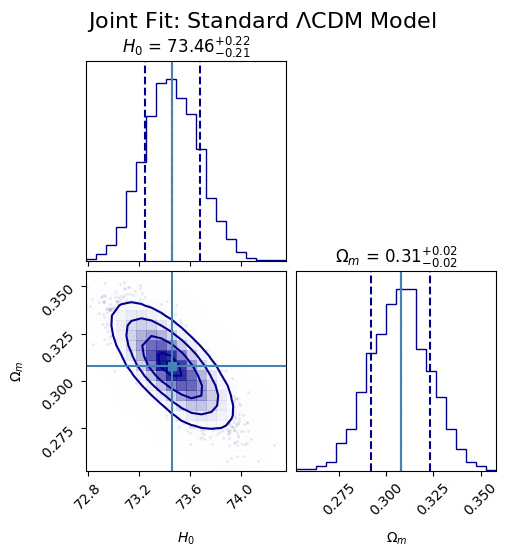

In [ ]:
import numpy as np
import pandas as pd
import urllib.request
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import time

# =====================================================================
# 1. LOAD DATA
# =====================================================================
print("1. Loading Pantheon+ and Cosmic Chronometers data...")
url_data = "https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat"
url_cov = "https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov"

df = pd.read_csv(url_data, sep=r'\s+')
response = urllib.request.urlopen(url_cov)
lines = response.readlines()
N_points = int(lines[0].decode('utf-8').strip())
C_matrix = np.loadtxt(lines[1:]).reshape((N_points, N_points))

df['original_index'] = np.arange(len(df))
data_filtered = df[df['zHD'] > 0.01].copy().sort_values(by='zHD')
keep_indices = data_filtered['original_index'].values

C_filtered = C_matrix[keep_indices, :][:, keep_indices]
C_inv = np.linalg.inv(C_filtered)

z_sn = data_filtered['zHD'].values
mu_sn = data_filtered['MU_SH0ES'].values
c = 299792.458

cc_data = np.array([
    [0.070, 69.0, 19.6],  [0.090, 69.0, 12.0],  [0.120, 68.6, 26.2],
    [0.170, 83.0, 8.0],   [0.179, 75.0, 4.0],   [0.199, 75.0, 5.0],
    [0.200, 72.9, 29.6],  [0.240, 79.6, 2.6],   [0.270, 77.0, 14.0],
    [0.280, 88.8, 36.6],  [0.352, 83.0, 14.0],  [0.3802, 83.0, 13.5],
    [0.400, 95.0, 17.0],  [0.4004, 77.0, 10.2], [0.4247, 87.1, 11.2],
    [0.4497, 92.8, 12.9], [0.470, 89.0, 50.0],  [0.4783, 80.9, 9.0],
    [0.480, 97.0, 62.0],  [0.593, 104.0, 13.0], [0.680, 92.0, 8.0],
    [0.781, 105.0, 12.0], [0.875, 125.0, 17.0], [0.880, 90.0, 40.0],
    [0.900, 117.0, 23.0], [1.037, 154.0, 20.0], [1.300, 168.0, 17.0],
    [1.363, 160.0, 33.6], [1.430, 177.0, 18.0], [1.530, 140.0, 14.0],
    [1.750, 202.0, 40.0], [1.965, 186.5, 50.4]
])
z_cc = cc_data[:, 0]
H_cc = cc_data[:, 1]
err_cc = cc_data[:, 2]

N_total = len(z_sn) + len(z_cc)

# =====================================================================
# 2. LAMBDA-CDM DEFINITION
# =====================================================================
def calc_mu_lcdm_fast(z_array, H0, Om):
    z_max = np.max(z_array)
    z_grid = np.linspace(0, z_max + 0.1, 300)

    E_z = np.sqrt(Om * (1.0 + z_grid)**3 + (1.0 - Om))
    integrand = 1.0 / E_z

    dC_grid = cumulative_trapezoid(integrand, z_grid, initial=0)
    dC_interp = interp1d(z_grid, dC_grid, kind='cubic')
    dC_vals = dC_interp(z_array)

    dL = (c / H0) * (1.0 + z_array) * dC_vals
    return 5.0 * np.log10(dL) + 25.0

def log_prior_lcdm(theta):
    H0, Om = theta
    if (50.0 < H0 < 90.0) and (0.05 < Om < 0.95):
        return 0.0
    return -np.inf

def log_likelihood_lcdm(theta):
    H0, Om = theta

    mu_model = calc_mu_lcdm_fast(z_sn, H0, Om)
    delta_mu = mu_sn - mu_model
    chi2_sn = delta_mu.T @ C_inv @ delta_mu

    H_model = H0 * np.sqrt(Om * (1.0 + z_cc)**3 + (1.0 - Om))
    chi2_cc = np.sum(((H_cc - H_model) / err_cc)**2)

    return -0.5 * (chi2_sn + chi2_cc)

def log_prob_lcdm(theta):
    lp = log_prior_lcdm(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_lcdm(theta)

# =====================================================================
# 3. RUN MCMC (2 PARAMETERS)
# =====================================================================
print("\n2. Running standard MCMC for Lambda-CDM (2 parameters)...")
initial_guess = np.array([73.0, 0.3])
ndim = 2
nwalkers = 32

pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)
sampler_lcdm = emcee.EnsembleSampler(nwalkers, ndim, log_prob_lcdm)

nsteps = 2000
t0 = time.time()
sampler_lcdm.run_mcmc(pos, nsteps, progress=True)
print(f"-> MCMC completed in {(time.time()-t0):.2f} seconds.")

# =====================================================================
# 4. RESULTS AND COMPARISON
# =====================================================================
discard = 500
flat_samples_lcdm = sampler_lcdm.get_chain(discard=discard, thin=15, flat=True)

flat_log_prob = sampler_lcdm.get_log_prob(discard=discard, thin=15, flat=True)
best_fit_index = np.argmax(flat_log_prob)
best_chi2_lcdm = -2.0 * flat_log_prob[best_fit_index]

k_params_lcdm = ndim
aic_lcdm = best_chi2_lcdm + 2 * k_params_lcdm
bic_lcdm = best_chi2_lcdm + k_params_lcdm * np.log(N_total)

print("\n" + "="*50)
print("JOINT ANALYSIS RESULTS - LAMBDA CDM (BASELINE):")
labels_lcdm = [r"$H_0$", r"$\Omega_m$"]
results_mcmc_lcdm = []
for i in range(ndim):
    mcmc = np.percentile(flat_samples_lcdm[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    results_mcmc_lcdm.append(mcmc[1])
    print(f"{labels_lcdm[i]:<10}: {mcmc[1]:.3f} +{q[1]:.3f} / -{q[0]:.3f}")

print("-" * 50)
print(f"Total data points (N)    : {N_total}")
print(f"Free parameters (k)      : {k_params_lcdm}")
print(f"Best-fit Joint Chi2      : {best_chi2_lcdm:.2f}")
print(f"AIC                      : {aic_lcdm:.2f}")
print(f"BIC                      : {bic_lcdm:.2f}")
print("="*50)

# Plot Corner
fig = corner.corner(
    flat_samples_lcdm,
    labels=labels_lcdm,
    truths=results_mcmc_lcdm,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    smooth=1.2,
    color="darkblue"
)
fig.suptitle(r"Joint Fit: Standard $\Lambda$CDM Model", fontsize=16, y=1.02)
plt.savefig('fig_lcdm_corner.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_lcdm.png', dpi=300, bbox_inches='tight')
plt.show()